# Noise Scan

Vary the JPA flux bias, with no pump on JPA, and vary the TWPA pump power and frequency and observe the down converted signals on the spectrum analyzer. 

VNA signal off. 

Sweep the DC flux bias using the Yokogawa in Voltage mode.  Control the pump on the TWPA using channel B of the WindFreak synthesizer.  

 


In [1]:
import json
import numpy as np
import pyvisa
import time
import hid # pip install hidapi
import skrf as rf
import matplotlib.pyplot as plt
import serial.tools.list_ports
from windfreak import SynthHD
from RsInstrument import RsInstrument, BinFloatFormat
from datetime import datetime
from pathlib import Path
import os
import sys
import matplotlib.colors as mcolors

rm = pyvisa.ResourceManager()
instruments = rm.list_resources()

In [3]:
ports = serial.tools.list_ports.comports()
for port in ports:
  #  print(f"Port Name:   {port.device}")
   # print(f"Description: {port.description}")
    #print(f"Hardware ID: {port.hwid}")  # Shows USB Vendor ID, Product ID, and Location string
   # print("-" * 30)
    if 'A3E5' in port.hwid:
        print(f"Windfreak is on COM port {port.device}")
        synth = SynthHD(port.device)  


Windfreak is on COM port COM4


In [4]:
synth.init()
channel_a = synth[0]
channel_b = synth[1]  

In [5]:
yoko = None
for instrument in instruments:
    if 'YOKOGAWA' in instrument:
        # Initialize instrument
        yoko = rm.open_resource(instrument) 
        break

In [6]:
spa = None
for instrument in instruments:
    if '7405' in instrument:
        spa = rm.open_resource(instrument) 
        break

In [8]:
print(yoko.query('*IDN?'))

YOKOGAWA,GS210,91U322681,2.02



In [9]:
spa_json = {}
spa_json['idn'] = spa.query('*IDN?').strip()
spa_json['fstart']    = float(spa.query(':SENS1:FREQ:START?'))
spa_json['fstop']     = float(spa.query(':SENS1:FREQ:STOP?'))
spa_json['numpoints'] = int(spa.query(':SENS1:SWEep:POINts?'))
spa_json['rbw']      = float(spa.query(':SENS:BAND?'))
spa_json['vbw'] = float(spa.query(':SENS:BAND:VID?'))
spa_json['unit'] = spa.query(":UNIT:POW?").strip()
spa.write(":SYST:LOCAL")
spa_json

{'idn': 'Hewlett-Packard, E7405A, SG45102671, A.14.04',
 'fstart': 6949999999.0,
 'fstop': 7000000001.0,
 'numpoints': 101,
 'rbw': 100000.0,
 'vbw': 100000.0,
 'unit': 'W'}

In [16]:
twpa_pump_frequency = 8.75e9
twpa_pump_power = -26.0
channel_b.frequency = twpa_pump_frequency
channel_b.power = twpa_pump_power
channel_b.enable = True


In [20]:
flux_bias_voltage = 1.1
yoko.write(":SOUR:LEV " + str(flux_bias_voltage))

15

In [58]:
twpa_pump_power = -26.5
channel_b.power = twpa_pump_power

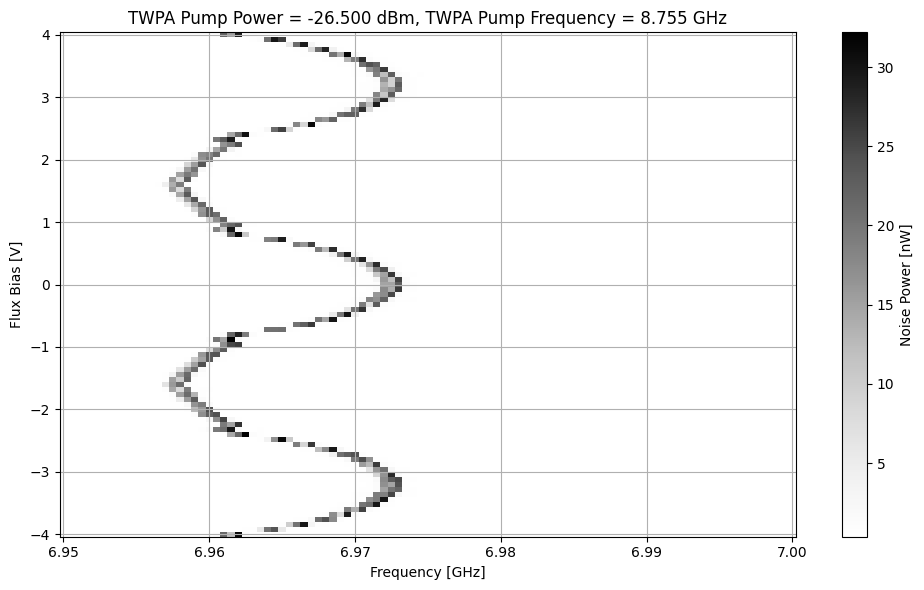

In [80]:
noise_scan = {}

noise_scan['twpa_pump_power'] = -26.5
noise_scan['twpa_pump_frequency'] = 8.755e9
channel_b.power = noise_scan['twpa_pump_power']
channel_b.frequency = noise_scan['twpa_pump_frequency']

flux_bias_start = -4
flux_bias_stop = 4
flux_bias_number_of_points = 101



now = datetime.now().astimezone()
noise_scan['timestamp'] = int(now.timestamp())
noise_scan['date'] = now.strftime("%d-%m-%Y")
noise_scan['time'] = now.strftime("%H:%M:%S")
noise_scan['timezone'] = now.tzname()

try:
    script_dir = Path(__file__).resolve().parent
except NameError:
    script_dir = Path.cwd()
folder_name = datetime.now().strftime("%d-%m-%Y")
target_dir = script_dir / folder_name
target_dir.mkdir(parents=True, exist_ok=True)

readme_path = target_dir / 'README.md'
if not readme_path.exists():
    readme_path.write_text("#  " + noise_scan['date'] + " Plots\n\n")


noise_scan['temperature'] = '0.017'
noise_scan['spectrum_analyzer'] = {}
noise_scan['spectrum_analyzer']['idn'] = spa.query('*IDN?').strip()
noise_scan['spectrum_analyzer']['fstart']    = float(spa.query(':SENS1:FREQ:START?'))
noise_scan['spectrum_analyzer']['fstop']     = float(spa.query(':SENS1:FREQ:STOP?'))
noise_scan['spectrum_analyzer']['numpoints'] = int(spa.query(':SENS1:SWEep:POINts?'))
noise_scan['spectrum_analyzer']['rbw']      = float(spa.query(':SENS:BAND?'))
noise_scan['spectrum_analyzer']['vbw'] = float(spa.query(':SENS:BAND:VID?'))
noise_scan['spectrum_analyzer']['unit'] = spa.query(":UNIT:POW?").strip()
noise_scan['flux_bias_unit'] = 'V' 

noise_scan['flux_bias'] = np.linspace(flux_bias_start, flux_bias_stop, flux_bias_number_of_points)

frequencies = np.linspace(spa_json['fstart'],spa_json['fstop'],spa_json['numpoints'])
fghz = frequencies/1e9
noise_scan['fghz'] = fghz

noise_scan['noise'] = []

spa.write(":UNIT:POW W")
spa.write("FORM REAL,32")
spa.write("INIT:CONT OFF")

spa.timeout = 30000  

noise_scan['noise'] = []

for flux_bias in noise_scan['flux_bias']:
    yoko.write(f":SOUR:LEV {flux_bias:.3f}")
    spa.write("INIT:IMM")
    spa.query("*OPC?") 
    spa_trace = np.array(spa.query_binary_values("TRAC? TRACE1", datatype="f", is_big_endian=True))
    noise_scan['noise'].append(spa_trace)
    time.sleep(0.05)
noise_scan['noise'] = np.array(noise_scan['noise'])
spa.write("INIT:CONT ON")
spa.write(":SYST:LOCAL")
yoko.write(f":SOUR:LEV 0.0")


plt.figure(figsize=(10, 6))


mesh = plt.pcolormesh(
    fghz, 
    noise_scan['flux_bias'], 
    noise_scan['noise']/1e-9, 
    shading='auto', 
    cmap='Greys'
)

plt.title(f"TWPA Pump Power = {noise_scan['twpa_pump_power']:.3f} dBm, TWPA Pump Frequency = {noise_scan['twpa_pump_frequency']/1e9:.3f} GHz")
plt.xlabel("Frequency [GHz]")
plt.ylabel("Flux Bias [V]")

cbar = plt.colorbar(mesh)
cbar.set_label("Noise Power [nW]")

plt.tight_layout()
plt.grid()
plot_file_name = f"{noise_scan['timestamp']}-noise-scan-plot.png"
with open(readme_path, "a") as file:
    file.write("![]("+ plot_file_name + ")\n")
plot_file_path = target_dir / plot_file_name
plt.savefig(plot_file_path, dpi=300, bbox_inches='tight')

plt.show()

scan_file_name = f"{noise_scan['timestamp']}-noise-scan.json"
file_path = target_dir / scan_file_name
noise_scan['noise'] = noise_scan['noise'].tolist()
noise_scan['flux_bias'] = [round(x, 3) for x in noise_scan['flux_bias']]
noise_scan['fghz'] = noise_scan['fghz'].tolist()

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(noise_scan, f, indent=4)

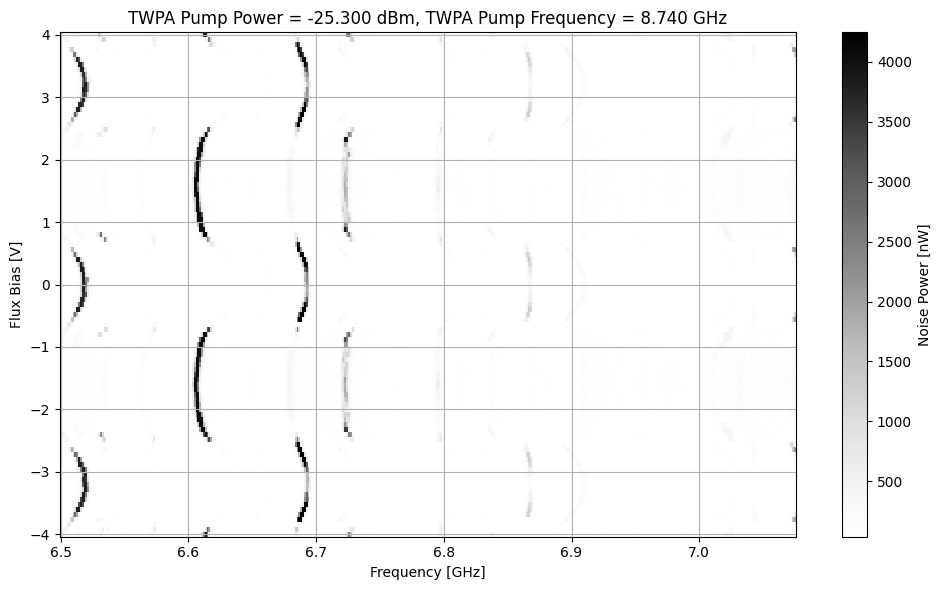

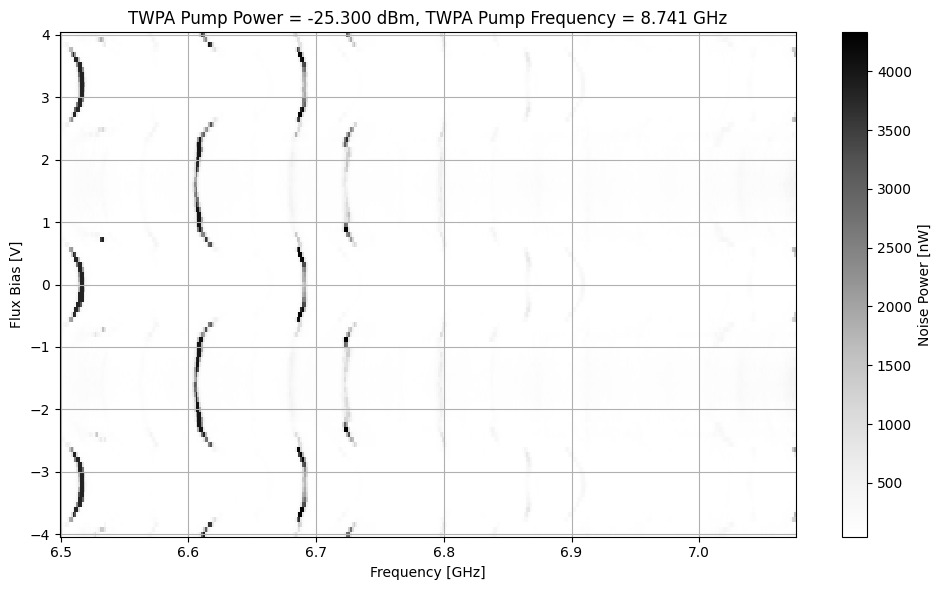

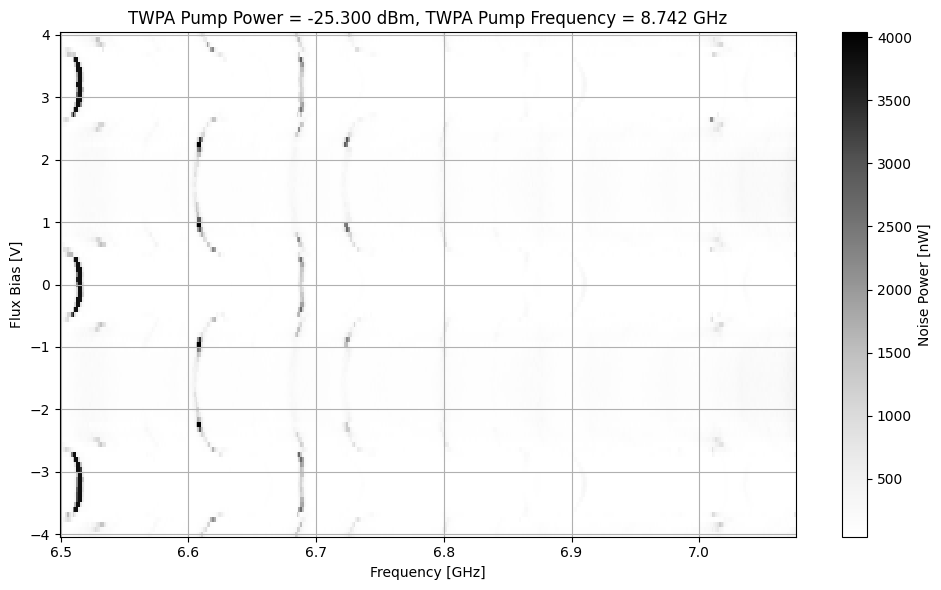

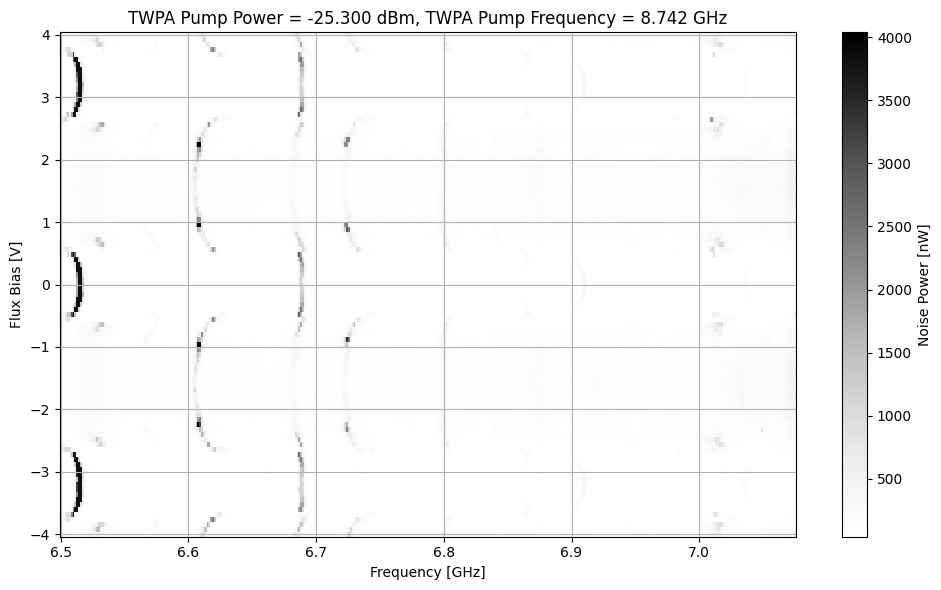

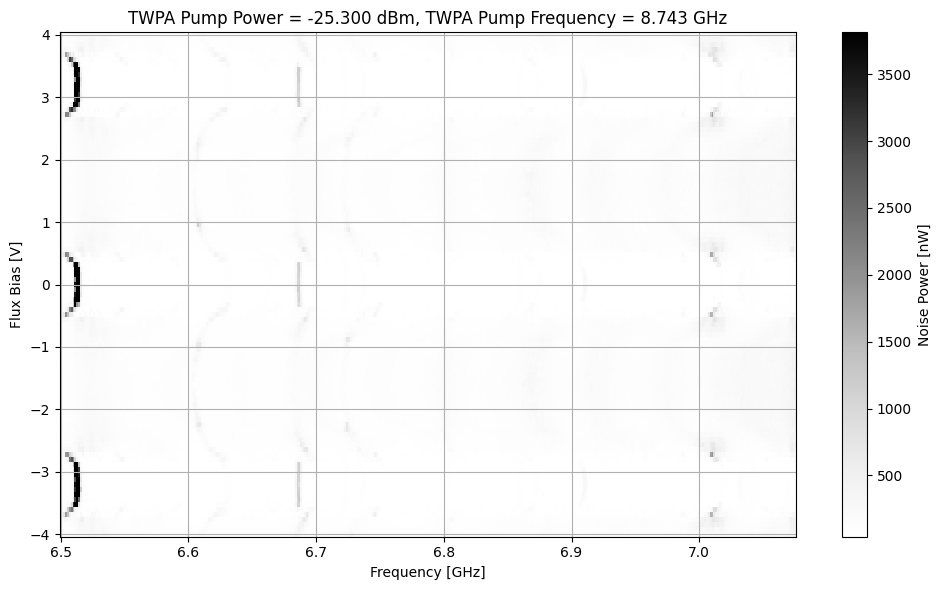

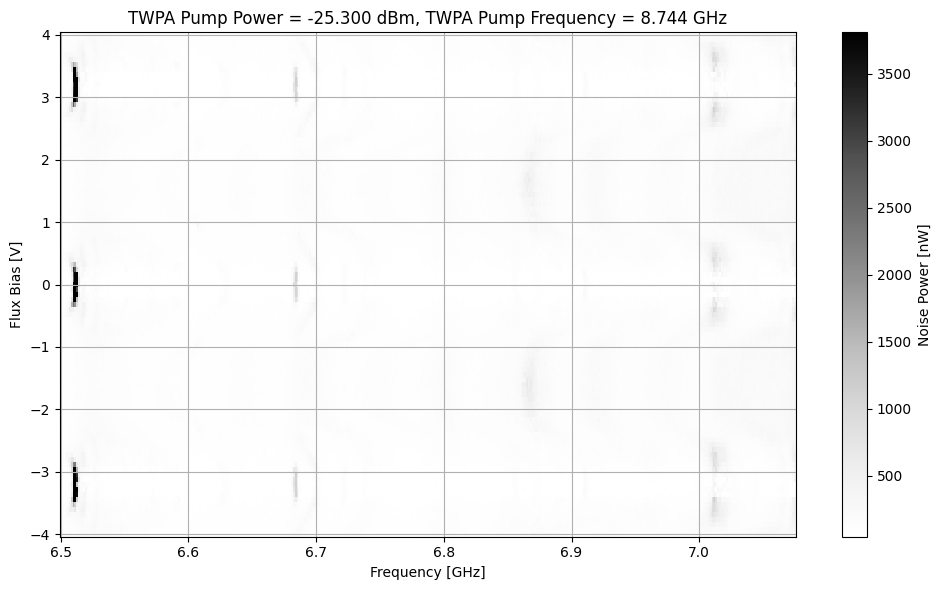

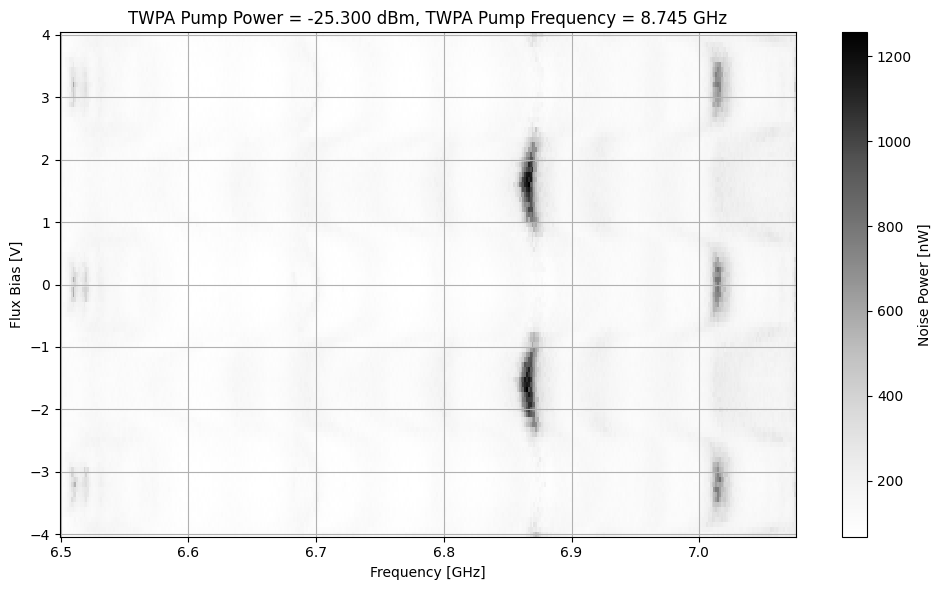

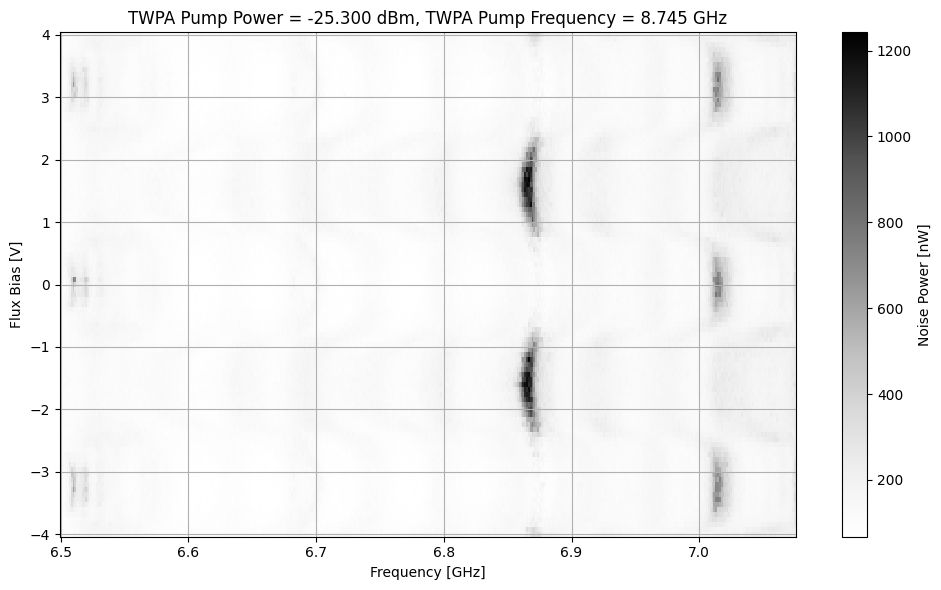

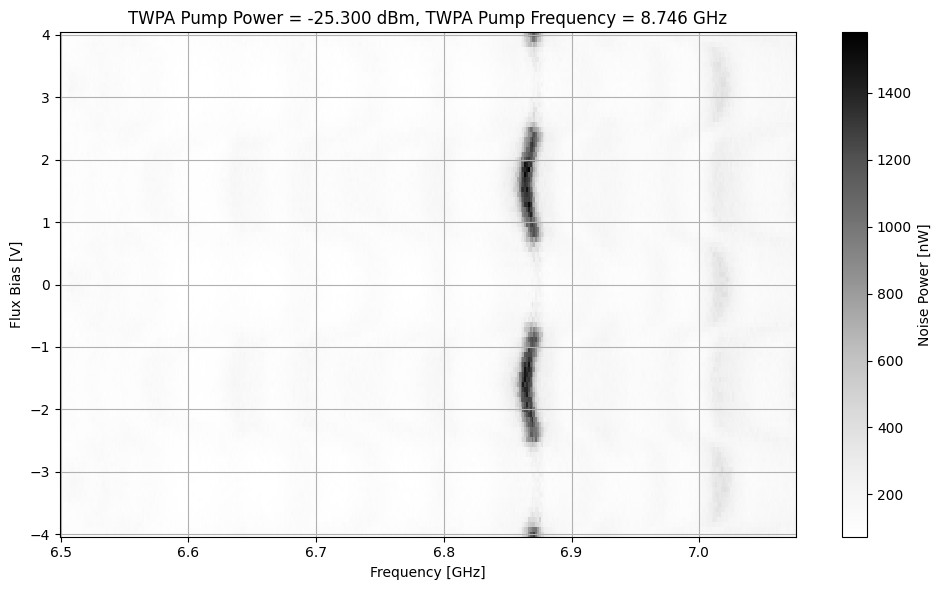

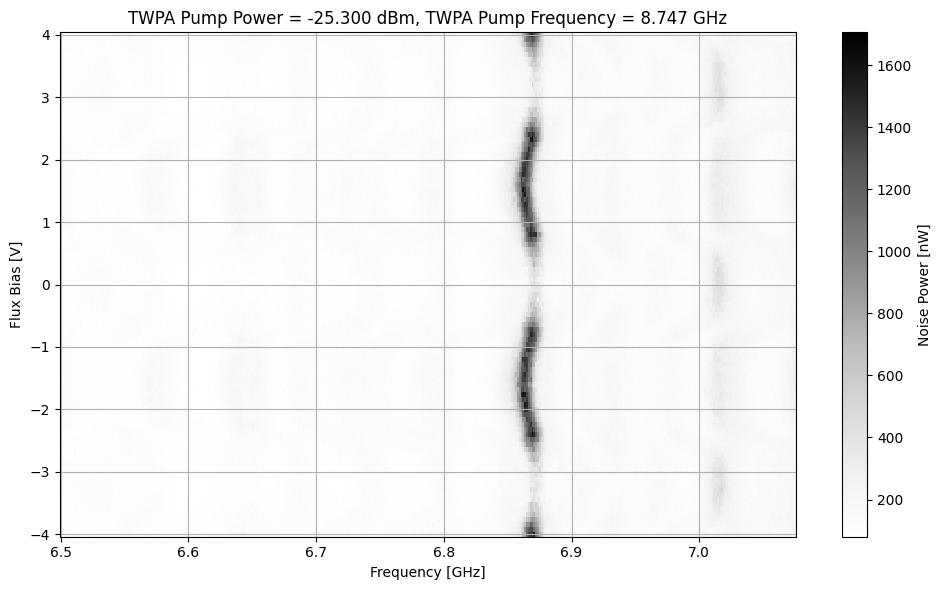

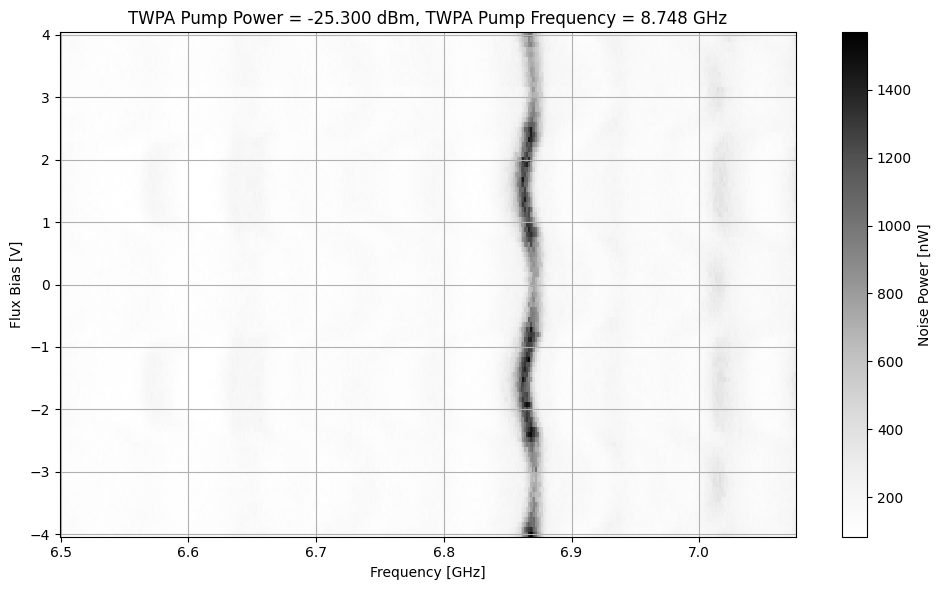

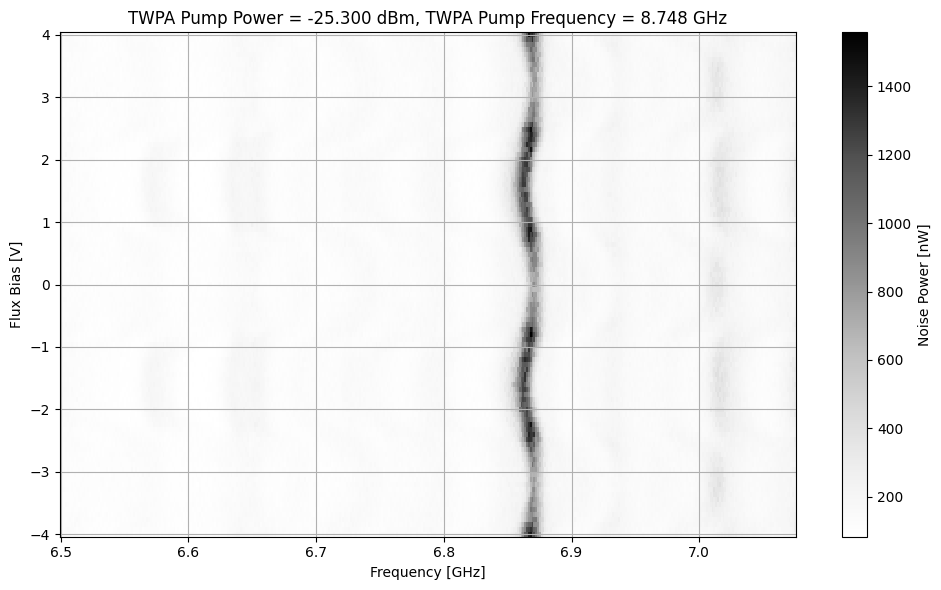

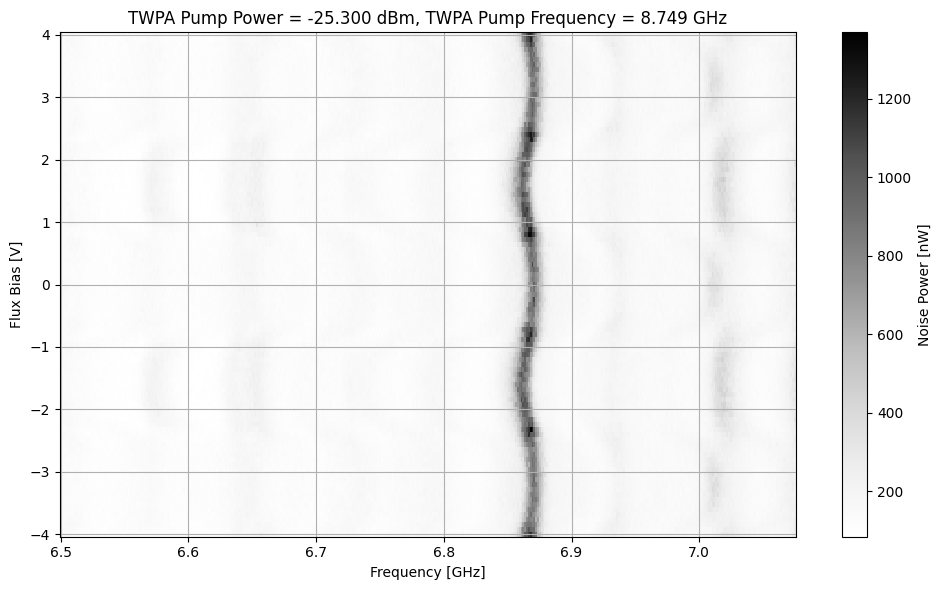

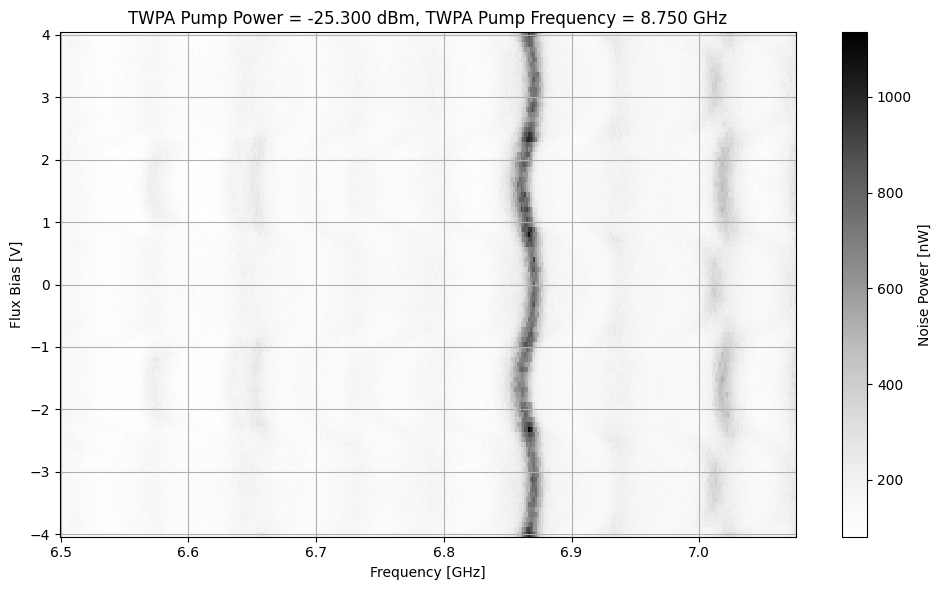

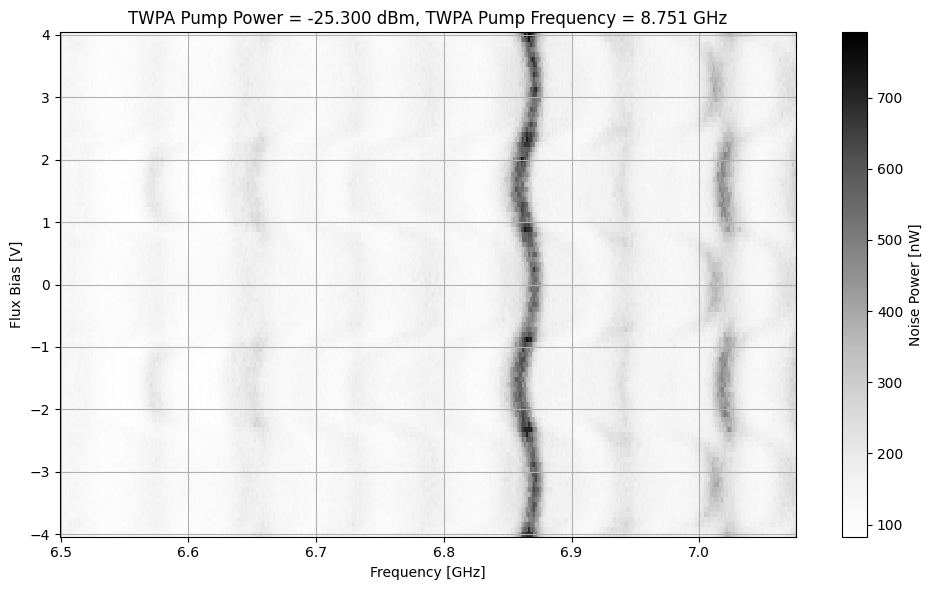

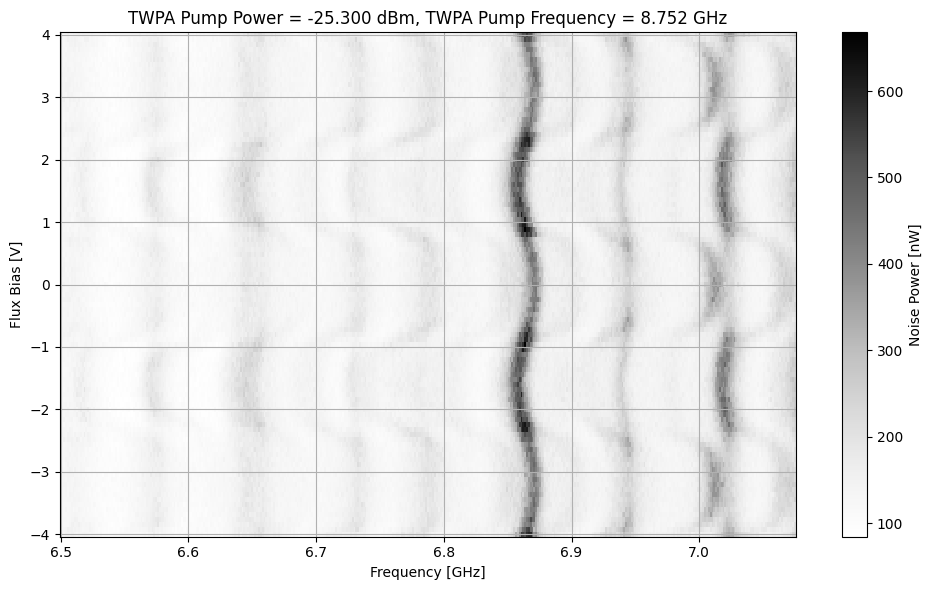

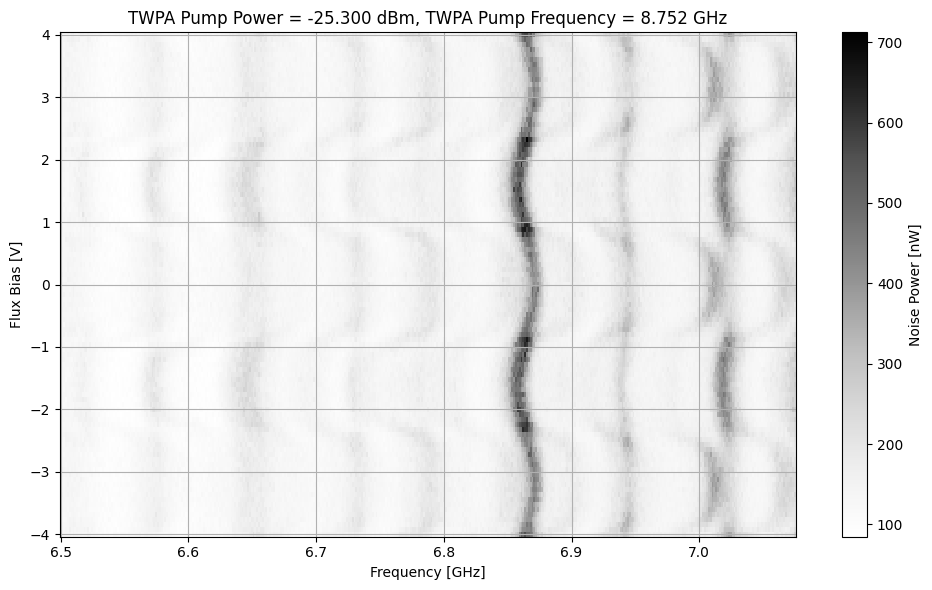

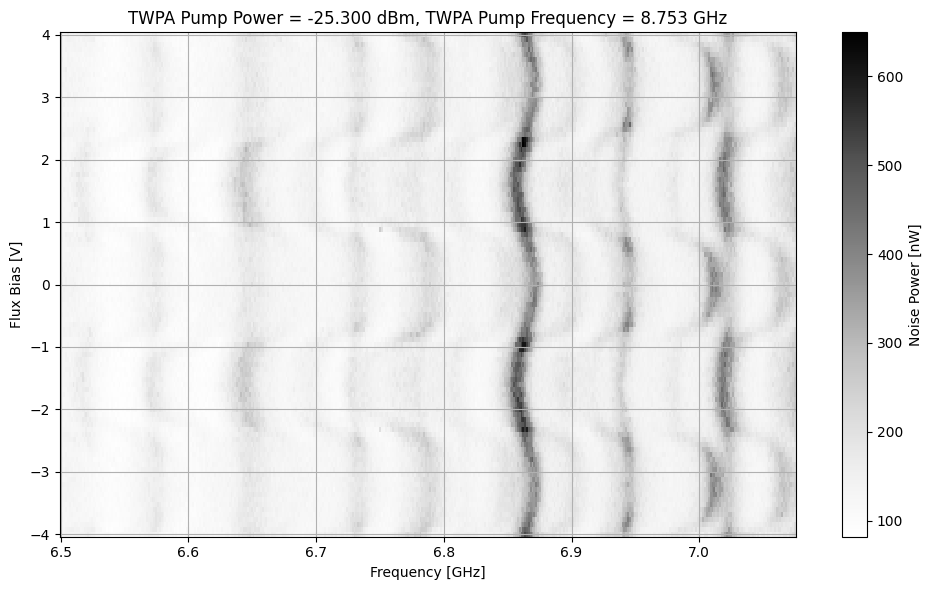

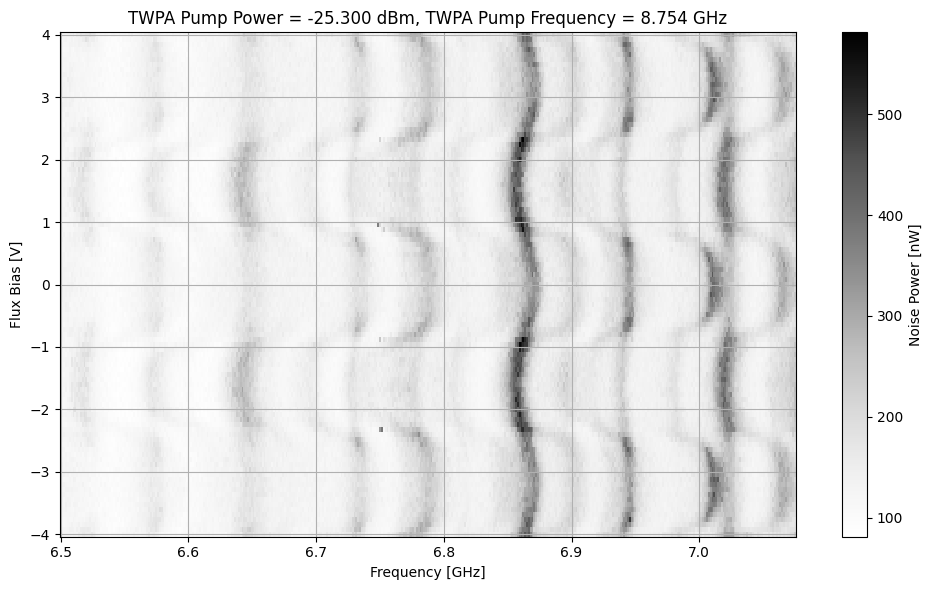

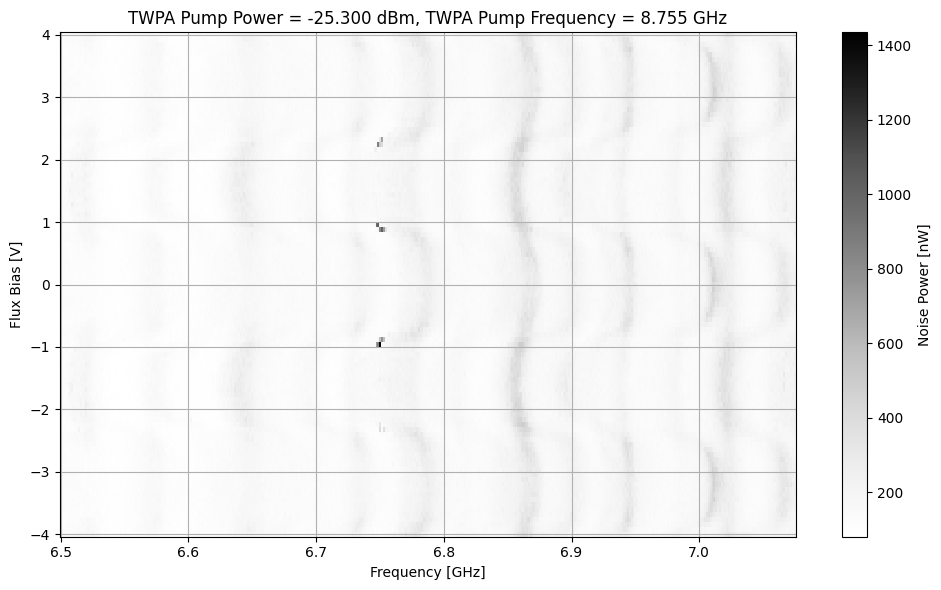

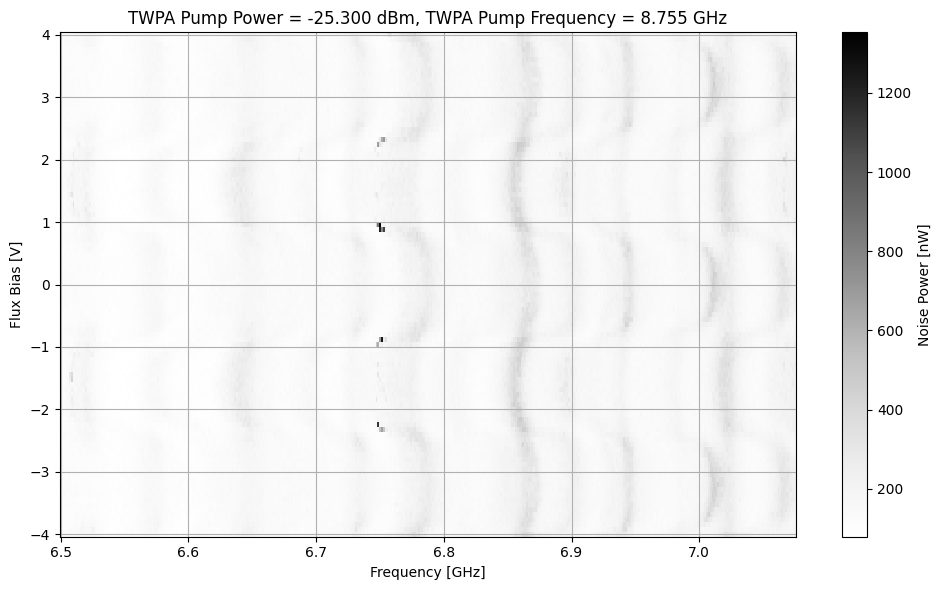

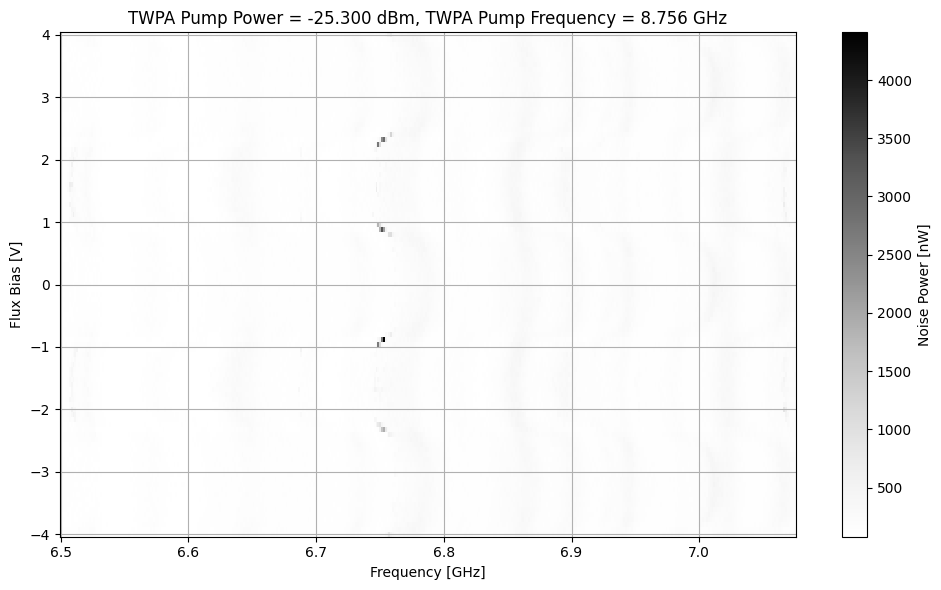

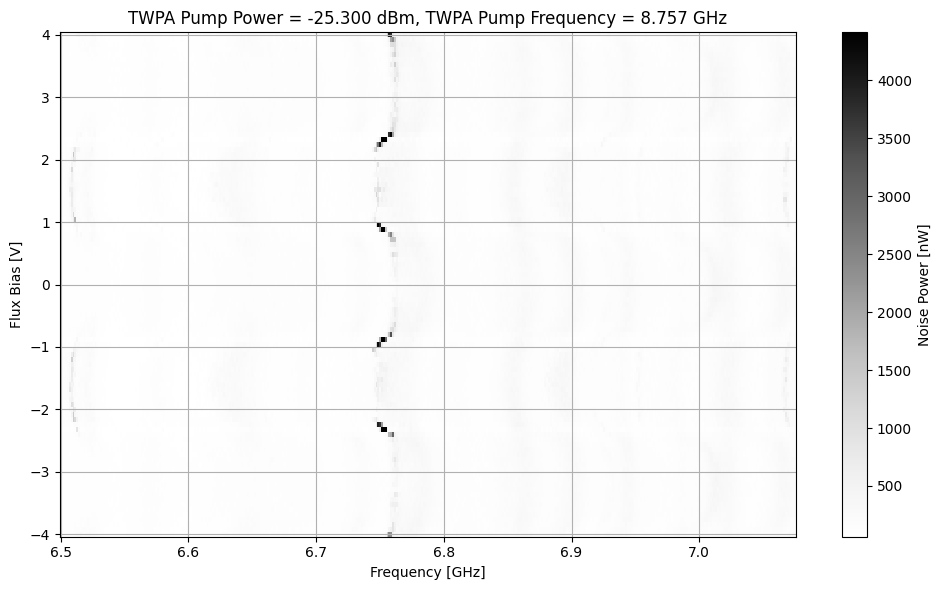

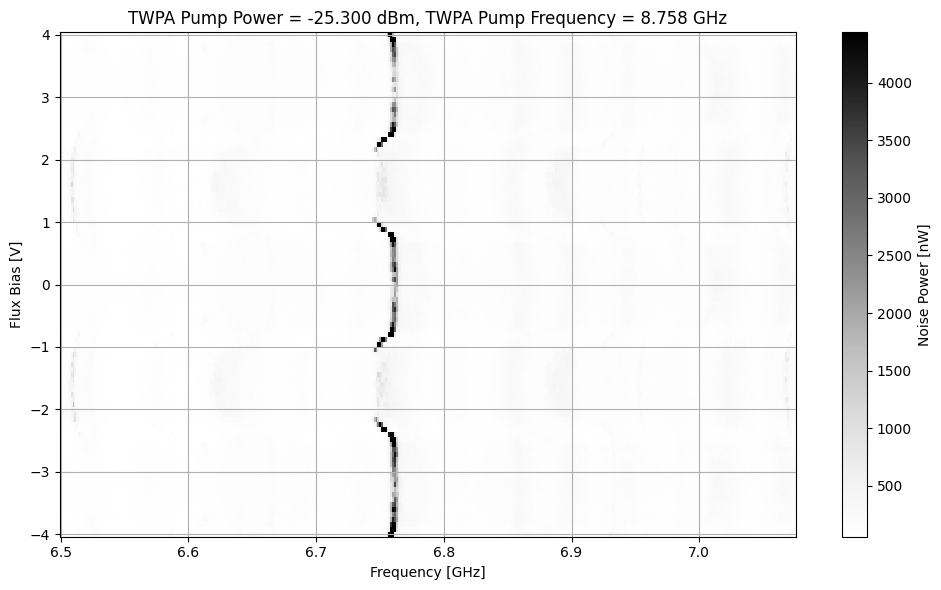

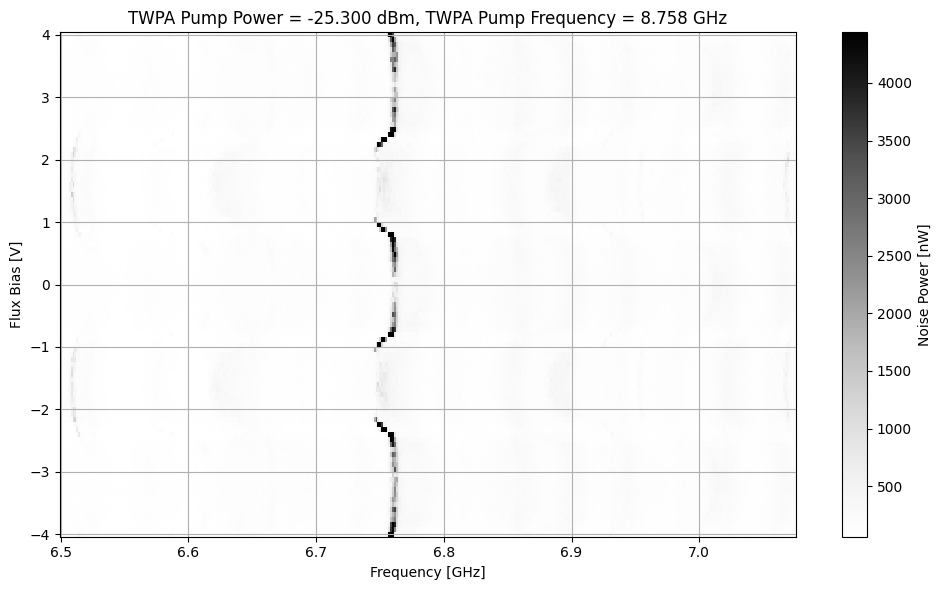

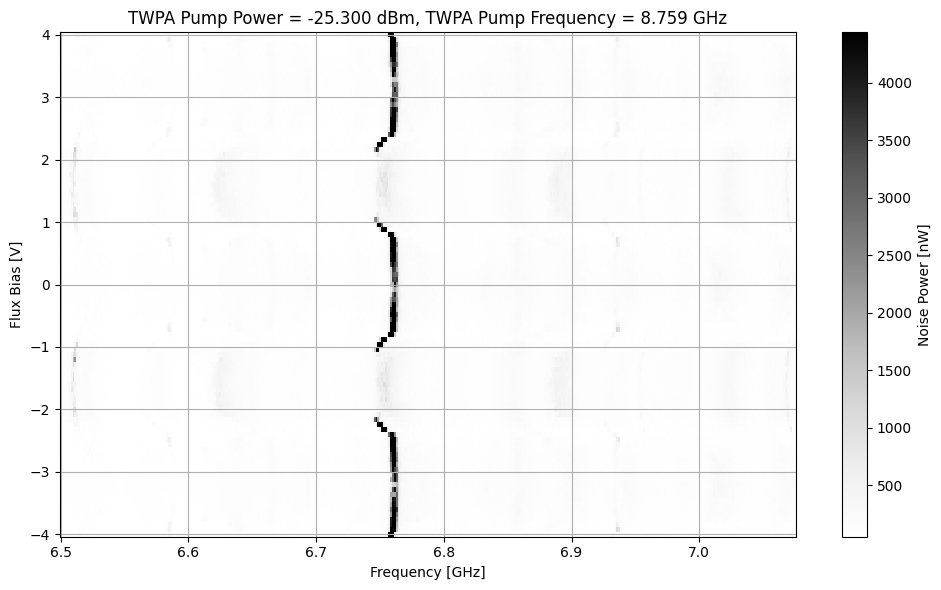

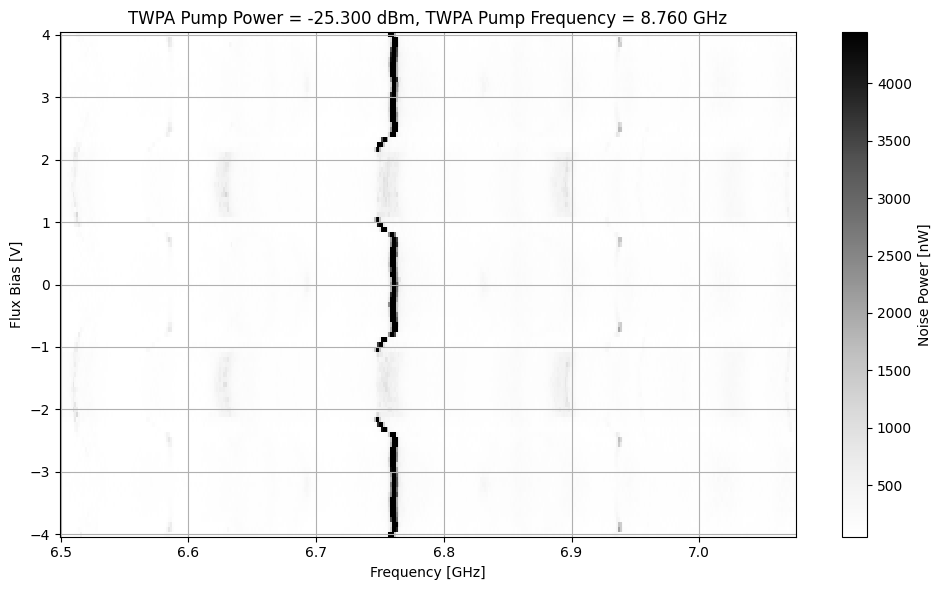

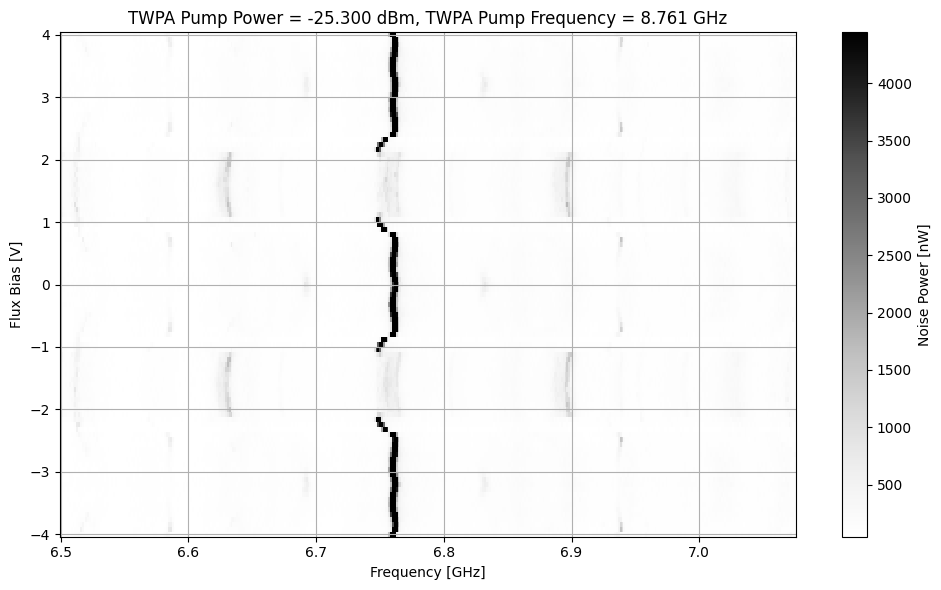

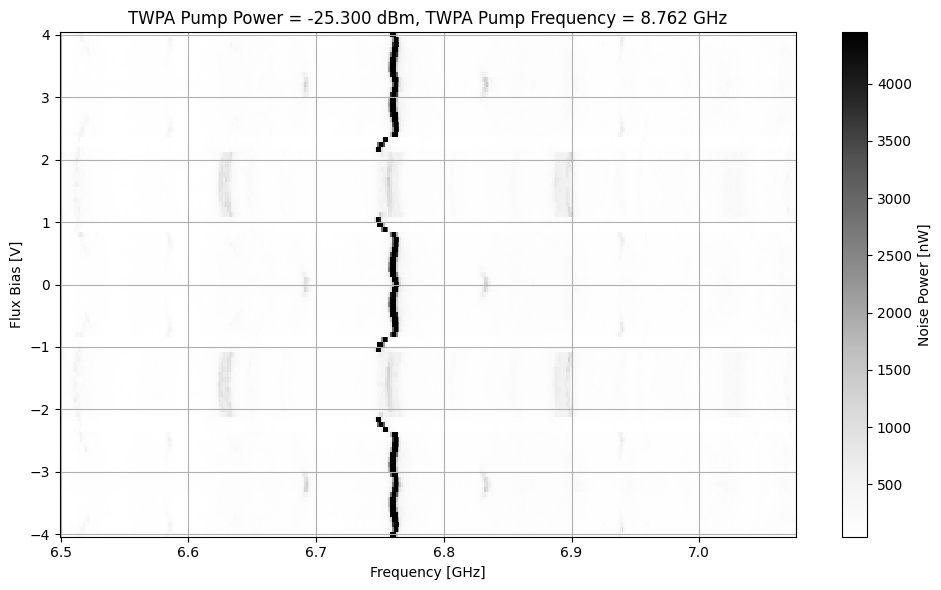

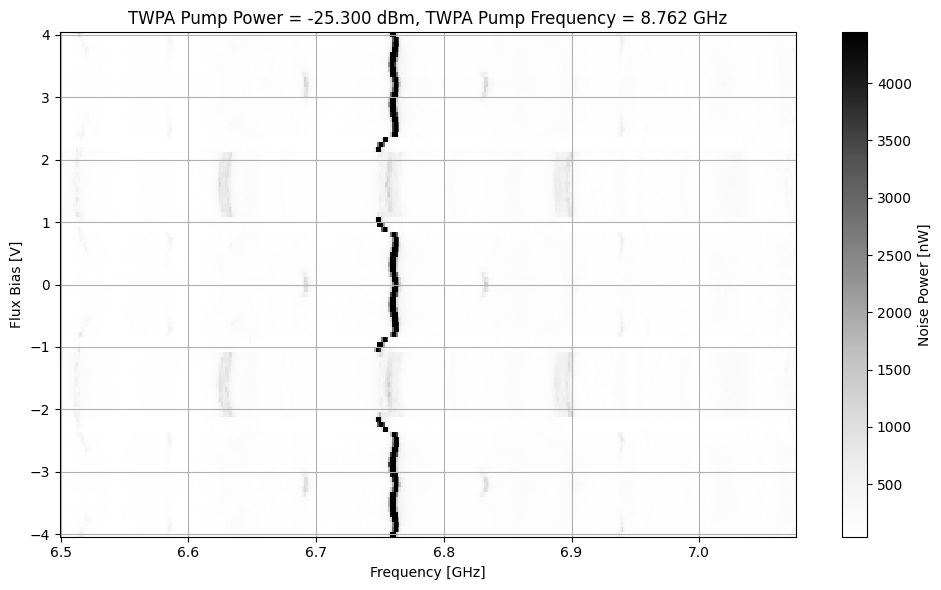

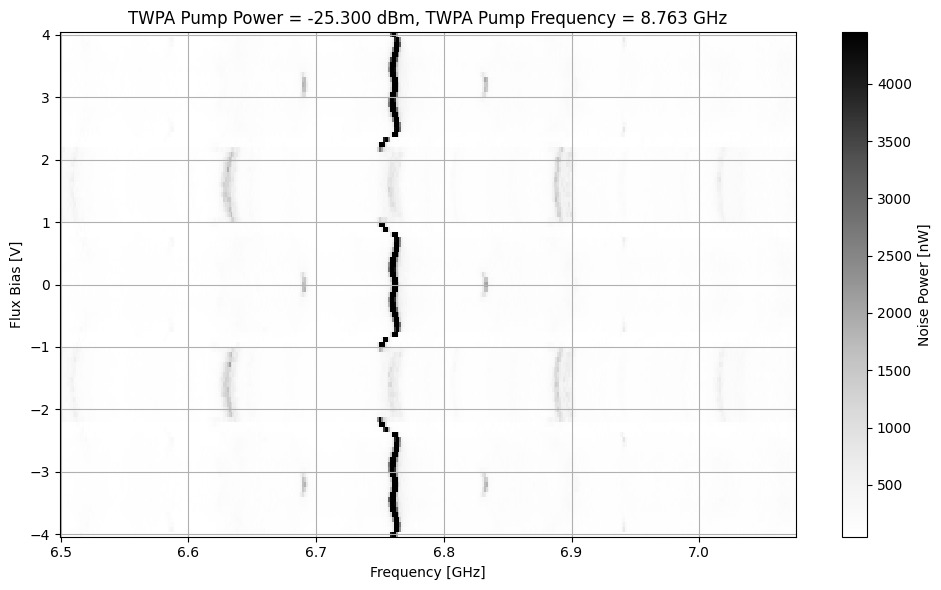

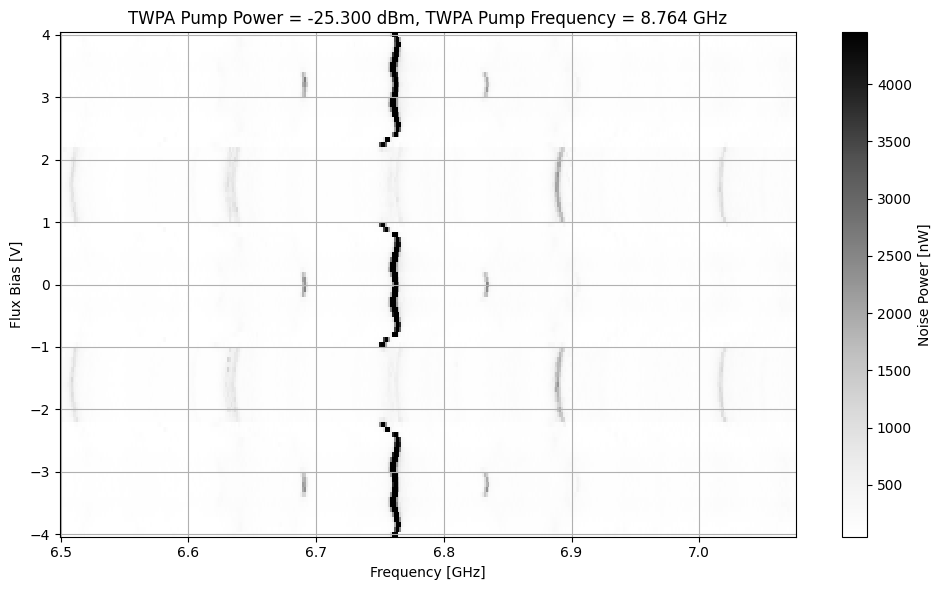

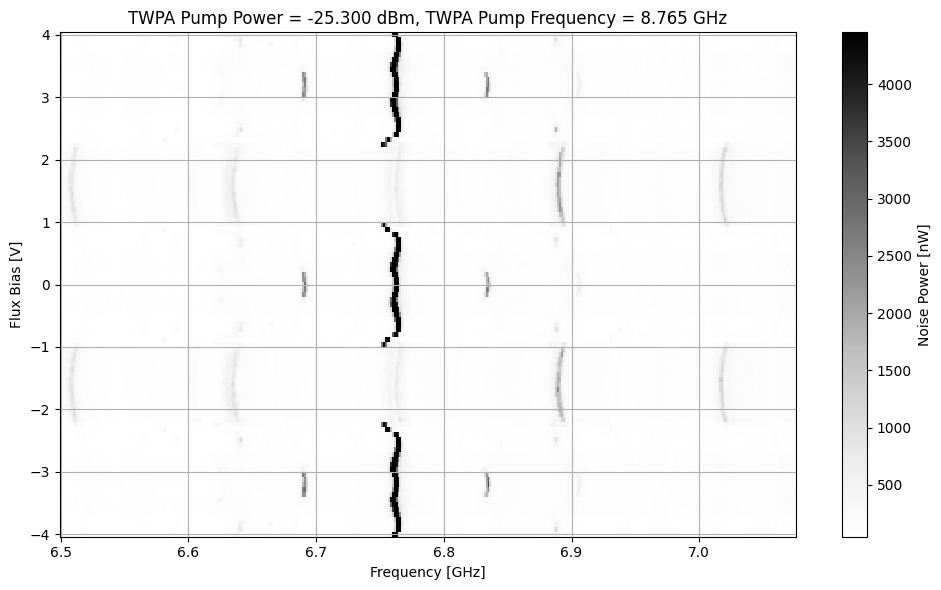

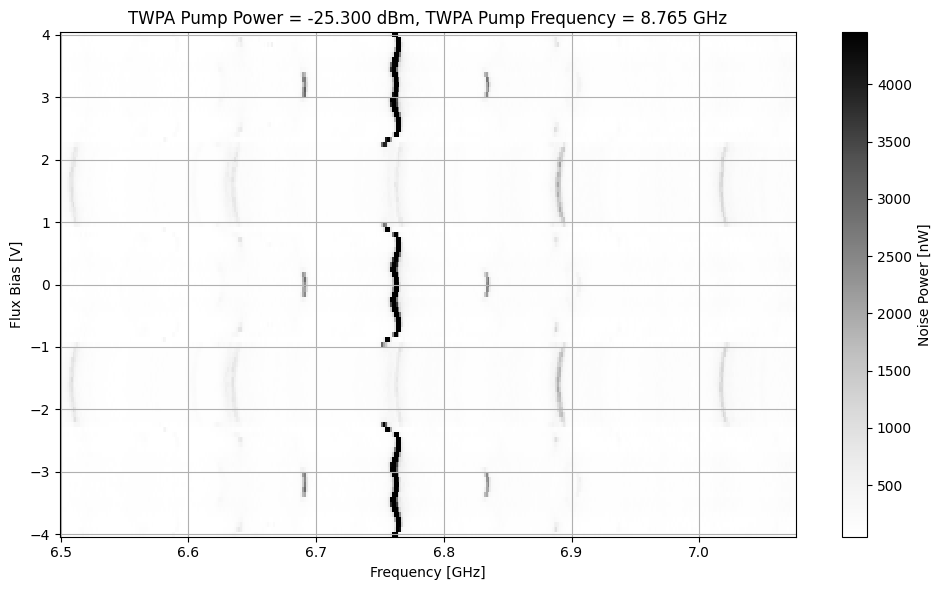

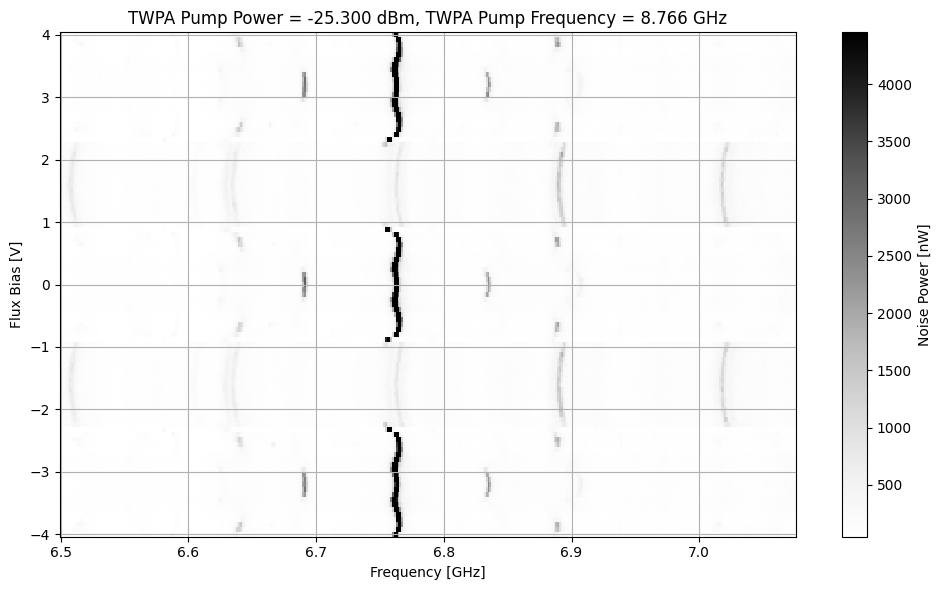

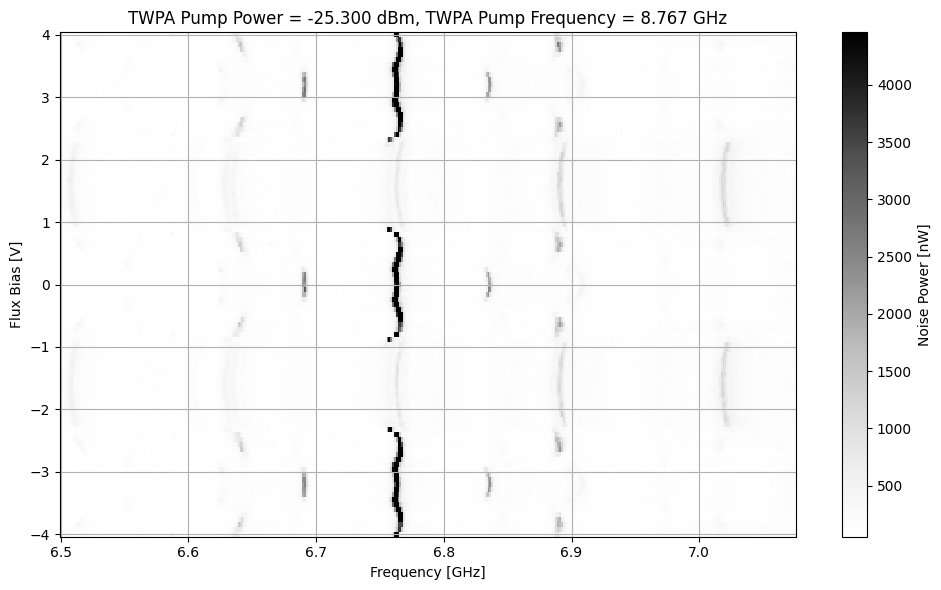

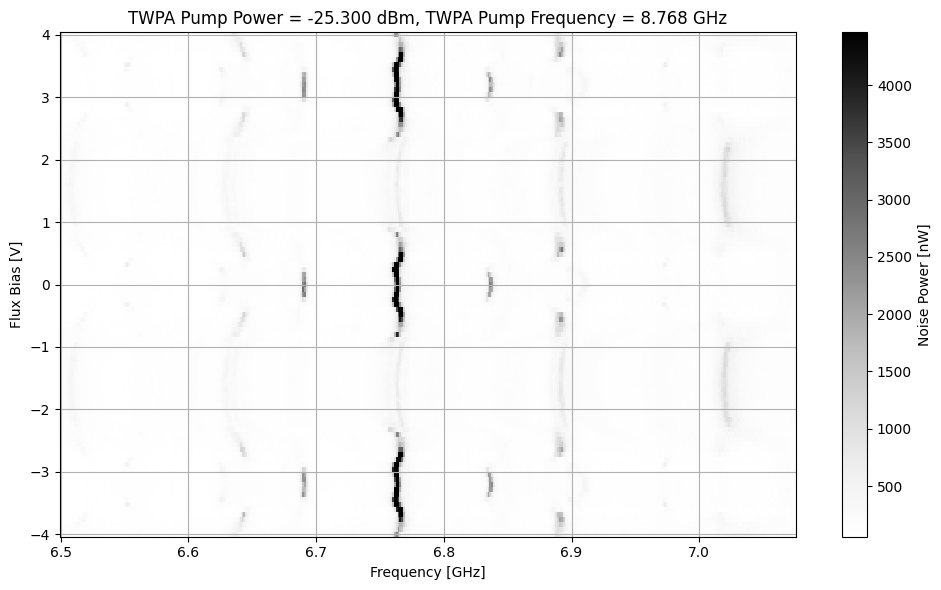

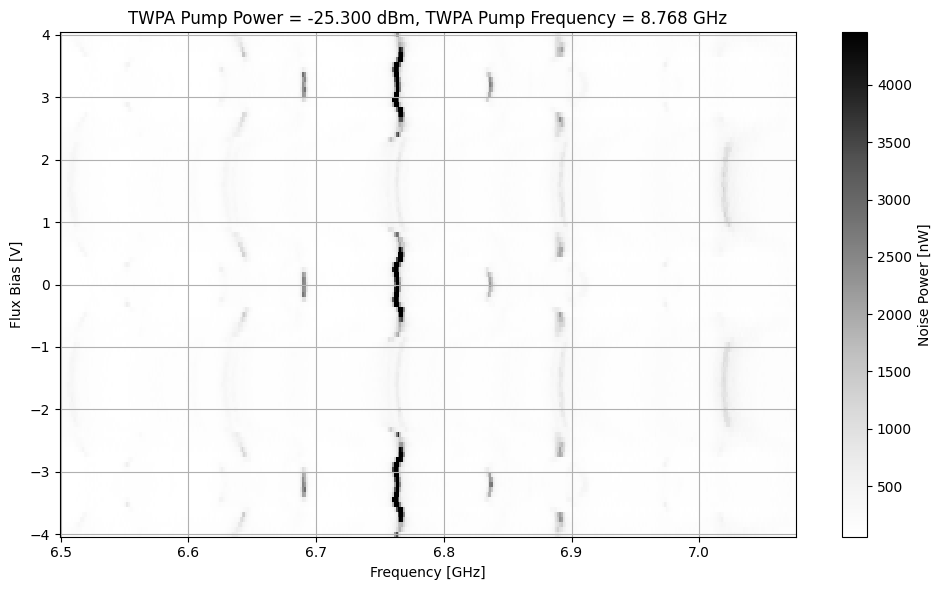

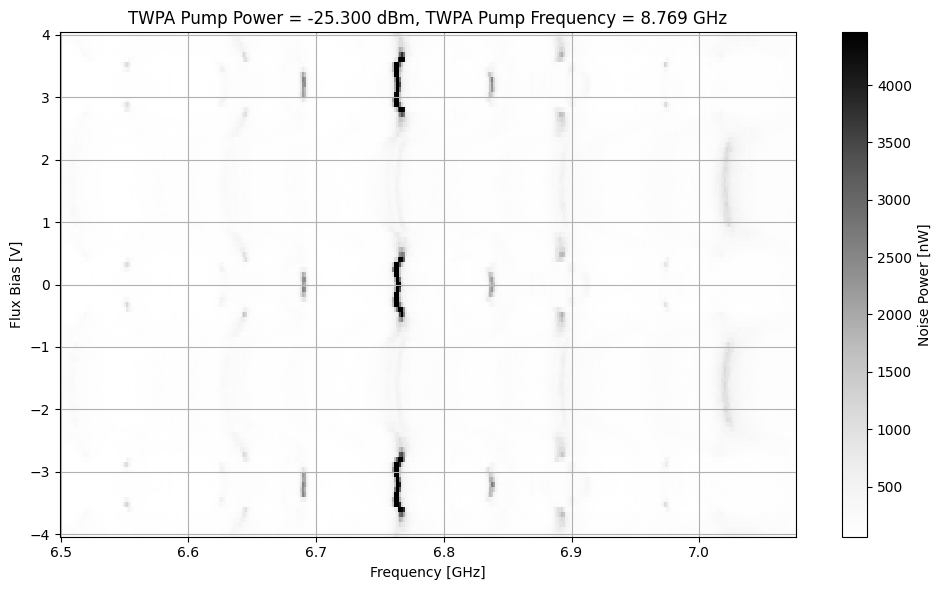

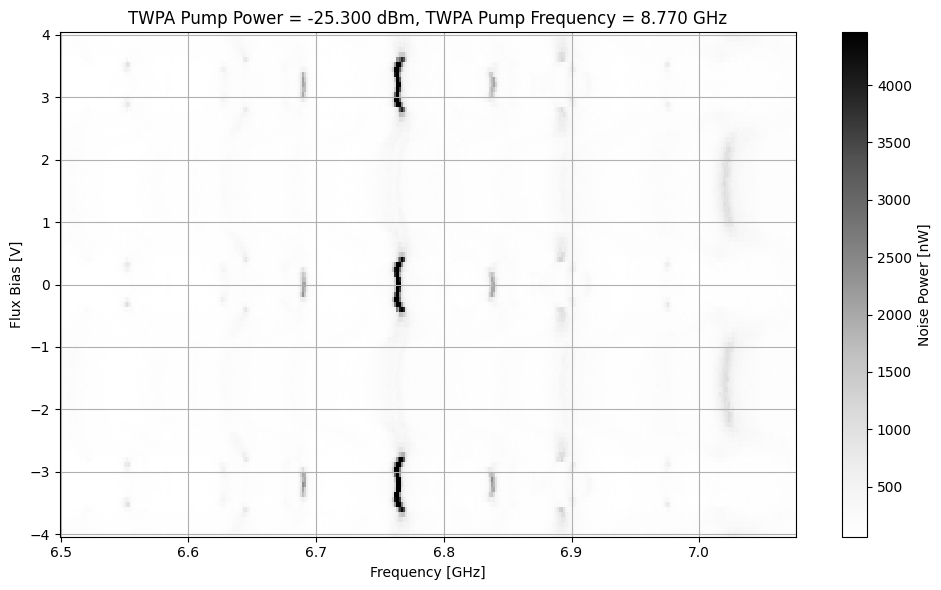

In [112]:

twpa_pump_frequency_start = 8.74e9
twpa_pump_frequency_stop = 8.77e9
twpa_pump_frequency_number_of_points = 40
tpwa_pump_frequency_sweep = np.linspace(twpa_pump_frequency_start, twpa_pump_frequency_stop, twpa_pump_frequency_number_of_points)
tpwa_pump_frequency_sweep = 1e6*np.round(tpwa_pump_frequency_sweep/1e6)

tpwa_pump_frequency_sweep_noise_scan =  {}

tpwa_pump_frequency_sweep_noise_scan['data_url_base'] = "https://raw.githubusercontent.com/lafefspietz/jpa-twpa-qubit-noise-summer-2026/refs/heads/main/"
tpwa_pump_frequency_sweep_noise_scan['plots'] = []
tpwa_pump_frequency_sweep_noise_scan['scans'] = []
tpwa_pump_frequency_sweep_noise_scan['twpa_pump_frequency'] = []

tpwa_pump_frequency_sweep_noise_scan['timestamp'] = int(now.timestamp())
tpwa_pump_frequency_sweep_noise_scan['date'] = now.strftime("%d-%m-%Y")
tpwa_pump_frequency_sweep_noise_scan['time'] = now.strftime("%H:%M:%S")
tpwa_pump_frequency_sweep_noise_scan['timezone'] = now.tzname()

for twpa_pump_frequency in tpwa_pump_frequency_sweep:
    noise_scan = {}
    tpwa_pump_frequency_sweep_noise_scan['twpa_pump_frequency'].append(twpa_pump_frequency)
    noise_scan['twpa_pump_power'] = -25.3
    noise_scan['twpa_pump_frequency'] = twpa_pump_frequency
    
    flux_bias_start = -4
    flux_bias_stop = 4
    flux_bias_number_of_points = 101
    
    channel_b.power = noise_scan['twpa_pump_power']
    channel_b.frequency = noise_scan['twpa_pump_frequency']
    
    now = datetime.now().astimezone()
    noise_scan['timestamp'] = int(now.timestamp())
    noise_scan['date'] = now.strftime("%d-%m-%Y")
    noise_scan['time'] = now.strftime("%H:%M:%S")
    noise_scan['timezone'] = now.tzname()
    
    try:
        script_dir = Path(__file__).resolve().parent
    except NameError:
        script_dir = Path.cwd()
    folder_name = datetime.now().strftime("%d-%m-%Y")
    target_dir = script_dir / folder_name
    target_dir.mkdir(parents=True, exist_ok=True)
    
    readme_path = target_dir / 'README.md'
    if not readme_path.exists():
        readme_path.write_text("#  " + noise_scan['date'] + " Plots\n\n")
    
    
    noise_scan['temperature'] = '0.017'
    noise_scan['spectrum_analyzer'] = {}
    noise_scan['spectrum_analyzer']['idn'] = spa.query('*IDN?').strip()
    noise_scan['spectrum_analyzer']['fstart']    = float(spa.query(':SENS1:FREQ:START?'))
    noise_scan['spectrum_analyzer']['fstop']     = float(spa.query(':SENS1:FREQ:STOP?'))
    noise_scan['spectrum_analyzer']['numpoints'] = int(spa.query(':SENS1:SWEep:POINts?'))
    noise_scan['spectrum_analyzer']['rbw']      = float(spa.query(':SENS:BAND?'))
    noise_scan['spectrum_analyzer']['vbw'] = float(spa.query(':SENS:BAND:VID?'))
    noise_scan['spectrum_analyzer']['unit'] = spa.query(":UNIT:POW?").strip()
    noise_scan['flux_bias_unit'] = 'V' 
    
    noise_scan['flux_bias'] = np.linspace(flux_bias_start, flux_bias_stop, flux_bias_number_of_points)
    
    frequencies = np.linspace(noise_scan['spectrum_analyzer']['fstart'],noise_scan['spectrum_analyzer']['fstop'],noise_scan['spectrum_analyzer']['numpoints'])

    
    fghz = frequencies/1e9
    noise_scan['fghz'] = fghz
    
    noise_scan['noise'] = []
    
    spa.write(":UNIT:POW W")
    spa.write("FORM REAL,32")
    spa.write("INIT:CONT OFF")
    
    spa.timeout = 60000  
    
    noise_scan['noise'] = []


    
    for flux_bias in noise_scan['flux_bias']:
        yoko.write(f":SOUR:LEV {flux_bias:.3f}")        
        while True:
            try:
                spa.write("INIT:IMM")
                spa.query("*OPC?") 
                spa_trace = np.array(spa.query_binary_values("TRAC? TRACE1", datatype="f", is_big_endian=True))
                break 
            except Exception:
                spa.clear()
                time.sleep(2.0) 
                
        noise_scan['noise'].append(spa_trace)
        time.sleep(0.1)


    noise_scan['noise'] = np.array(noise_scan['noise'])
    spa.write("INIT:CONT ON")
    spa.write(":SYST:LOCAL")
    yoko.write(f":SOUR:LEV 0.0")
    
    
    plt.figure(figsize=(10, 6))
    
    
    mesh = plt.pcolormesh(
        fghz, 
        noise_scan['flux_bias'], 
        noise_scan['noise']/1e-9, 
        shading='auto', 
        cmap='Greys'
    )
    
    plt.title(f"TWPA Pump Power = {noise_scan['twpa_pump_power']:.3f} dBm, TWPA Pump Frequency = {noise_scan['twpa_pump_frequency']/1e9:.3f} GHz")
    plt.xlabel("Frequency [GHz]")
    plt.ylabel("Flux Bias [V]")
    
    cbar = plt.colorbar(mesh)
    cbar.set_label("Noise Power [nW]")
    
    plt.tight_layout()
    plt.grid()
    plot_file_name = f"{noise_scan['timestamp']}-noise-scan-plot.png"

    with open(readme_path, "a") as file:
        file.write("![]("+ plot_file_name + ")\n")
    plot_file_path = target_dir / plot_file_name
    plt.savefig(plot_file_path, dpi=300, bbox_inches='tight')

    tpwa_pump_frequency_sweep_noise_scan['plots'].append(tpwa_pump_frequency_sweep_noise_scan['data_url_base'] + folder_name + "/" + plot_file_name)

    
    plt.show()
    
    scan_file_name = f"{noise_scan['timestamp']}-noise-scan.json"
    file_path = target_dir / scan_file_name
    noise_scan['noise'] = noise_scan['noise'].tolist()
    noise_scan['flux_bias'] = [round(x, 3) for x in noise_scan['flux_bias']]
    noise_scan['fghz'] = noise_scan['fghz'].tolist()
    
    with open(file_path, "w", encoding="utf-8") as f:
        json.dump(noise_scan, f, indent=4)
    tpwa_pump_frequency_sweep_noise_scan['scans'].append(tpwa_pump_frequency_sweep_noise_scan['data_url_base'] + folder_name + "/" + scan_file_name)
        
    plt.close()
    time.sleep(0.2)

current_timestamp = int(time.time())
tpwa_pump_frequency_sweep_noise_scan['timestamp'] = current_timestamp
frequency_sweep_file_name = str(tpwa_pump_frequency_sweep_noise_scan['timestamp']) + "-frequency-sweep-noise-scans.json"

file_path = target_dir / frequency_sweep_file_name

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(tpwa_pump_frequency_sweep_noise_scan, f, indent=4)

In [121]:
noise_scan['twpa_pump_power'] = -26.7
noise_scan['twpa_pump_frequency'] = 8.77e9
channel_b.power = noise_scan['twpa_pump_power']
channel_b.frequency = noise_scan['twpa_pump_frequency']
